# Test 4: Reported Agency vs. Pressure Signal Quality

Does the quality of the pressure signal affect how much agency participants report? This notebook looks at test 4 sessions — the mock final test run before the full study (test 5).

**Quality metrics available:**
- `avg_coverage` — mean IMU data coverage across L/R insoles (% of session with valid data)
- `avg_abs_heel_corr` — mean absolute heel correlation between IMU and pressure (alignment quality)
- `flag_count` — number of data quality flags raised during processing
- `pressure_missing` — whether any pressure file exists at all for this participant

**Agency metrics** (all 0–10 scale):
- `agency_q1` — "The sound influenced my movement"
- `agency_q2` — "My movement influenced the sound"  
- `agency_q3` — "I felt in control of the interaction"
- `agency_aggregate` — mean of q1–q3

> **Baseline caveat:** n = 6 sessions have both agency ratings and coverage/heel-corr data. A Spearman correlation needs r > 0.81 to reach p < 0.05 at this sample size — treat all results as descriptive.

In [12]:
import re
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats

DB_PATH = Path("../data/gait_study.db")
ALIGNMENT_CSV = Path("test5_alignment_report.csv")
TEST4_RAW = Path("../data/Test 4/Raw data")

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## 1. Load & merge data

In [13]:
# --- Agency ratings from DB ---
EXCLUDE_PIDS = {"01", "02", "22"}

con = sqlite3.connect(DB_PATH)
agency_df = pd.read_sql_query(
    """
    SELECT s.session_id, s.participant_id, s.notes AS session_notes,
           sr.agency_q1, sr.agency_q2, sr.agency_q3, sr.agency_aggregate
    FROM sessions s
    JOIN session_ratings sr ON sr.session_id = s.session_id
    WHERE s.test_type_id = 4
    ORDER BY s.session_id
    """,
    con,
)
con.close()

agency_df = agency_df[~agency_df["participant_id"].isin(EXCLUDE_PIDS)].reset_index(drop=True)

# --- Alignment report ---
align_df = pd.read_csv(ALIGNMENT_CSV)
align_df["session_id"] = align_df["session_id"].astype(int)

df = agency_df.merge(
    align_df[["session_id", "flags", "imu_l_coverage_pct", "imu_r_coverage_pct", "notes"]],
    on="session_id",
    how="left",
)

# --- Parse heel correlations from notes ---
def parse_heel_corr(notes):
    if not isinstance(notes, str):
        return None, None
    l = re.search(r"L heel corr=([-\d.]+)", notes)
    r = re.search(r"R heel corr=([-\d.]+)", notes)
    return (float(l.group(1)) if l else None), (float(r.group(1)) if r else None)

df[["heel_corr_l", "heel_corr_r"]] = df["notes"].apply(
    lambda n: pd.Series(parse_heel_corr(n))
)

# --- Derived quality metrics ---
df["avg_coverage"]       = df[["imu_l_coverage_pct", "imu_r_coverage_pct"]].mean(axis=1)
df["avg_abs_heel_corr"]  = df[["heel_corr_l", "heel_corr_r"]].abs().mean(axis=1)
df["flag_count"]         = df["flags"].apply(
    lambda f: len([x for x in f.split("|") if x.strip()]) if isinstance(f, str) else 0
)

# Pressure missing = no file with "pressure" in name exists for this participant
def has_no_pressure(pid):
    folder = TEST4_RAW / str(pid).zfill(2)
    if not folder.exists():
        return True
    return not any(folder.glob("*pressure*"))

df["pressure_missing"] = df["participant_id"].apply(has_no_pressure)

print(f"Excluded: {sorted(EXCLUDE_PIDS)}")
print(f"Sessions remaining: {len(df)}")
print(f"  — with coverage/heel-corr data: {df['avg_coverage'].notna().sum()}")
print(f"  — pressure missing:             {df['pressure_missing'].sum()}")
df[["session_id", "participant_id", "agency_aggregate",
    "avg_coverage", "avg_abs_heel_corr", "flag_count", "pressure_missing",
    "session_notes"]].sort_values("agency_aggregate")

Excluded: ['01', '02', '22']
Sessions remaining: 6
  — with coverage/heel-corr data: 6
  — pressure missing:             0


,session_id,participant_id,agency_aggregate,avg_coverage,avg_abs_heel_corr,flag_count,pressure_missing,session_notes
5,65,28,6.666667,77.70,0.2525,6,False,
3,63,27,7.333333,72.85,0.1130,7,False,
0,60,24,8.000000,93.30,0.0565,6,False,no issues!!
2,62,26,8.000000,86.35,0.0425,7,False,"latency was really good at the start, then got..."
1,61,25,8.333333,100.00,0.2300,4,False,"is a dancer, maintained rlly good BPM."
4,64,08,10.000000,74.85,0.3260,7,False,


## 3. Agency vs. continuous quality metrics

For sessions where pressure data exists, do finer-grained quality metrics (IMU coverage %, heel correlation) track agency?

Plotting 6 sessions: ['08', '24', '25', '26', '27', '28']


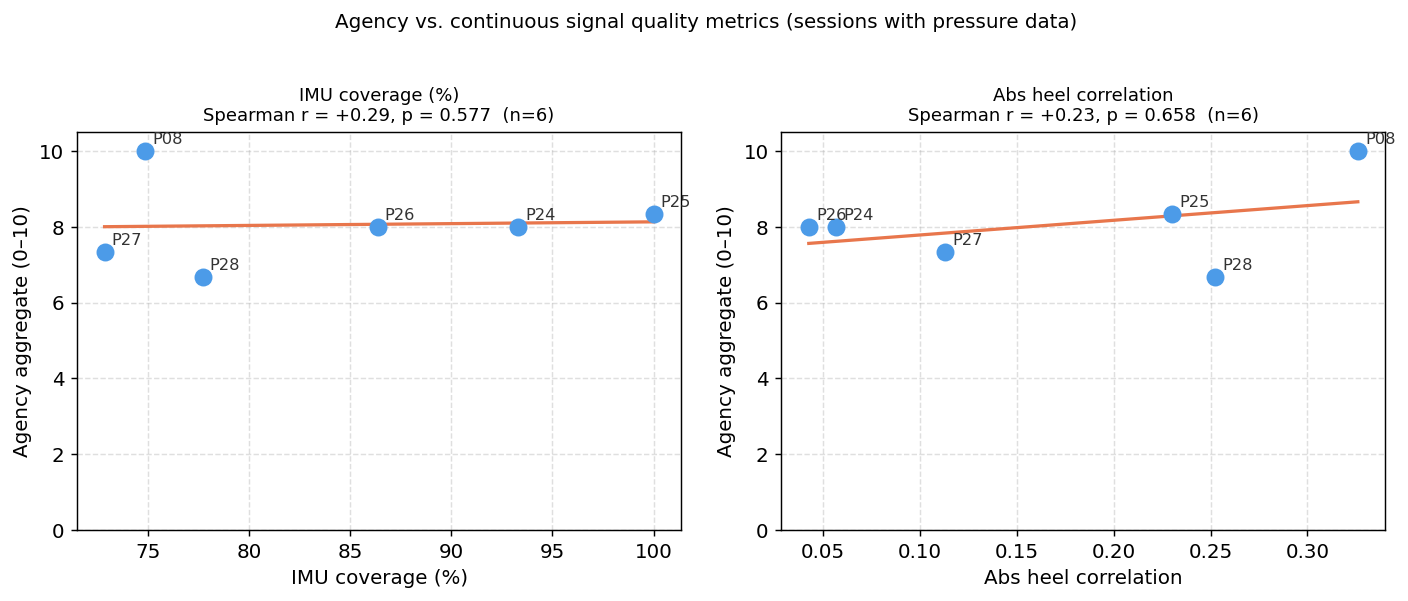

In [14]:
sub = df.dropna(subset=["avg_coverage", "avg_abs_heel_corr"]).copy()
print(f"Plotting {len(sub)} sessions: {sorted(sub['participant_id'].tolist())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

metrics = [
    ("avg_coverage",      "IMU coverage (%)"),
    ("avg_abs_heel_corr", "Abs heel correlation"),
]

for ax, (col, xlabel) in zip(axes, metrics):
    x_vals = sub[col].values
    y_vals = sub["agency_aggregate"].values
    pids   = sub["participant_id"].values

    ax.scatter(x_vals, y_vals, s=80, color="#4C9BE8", zorder=3)
    for xi, yi, pid in zip(x_vals, y_vals, pids):
        ax.annotate(f"P{pid}", xy=(xi, yi), xytext=(4, 4),
                    textcoords="offset points", fontsize=9, color="#333")

    slope, intercept, *_ = stats.linregress(x_vals, y_vals)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="#E8764C", linewidth=1.8, zorder=2)

    rho, p_s = stats.spearmanr(x_vals, y_vals)
    ax.set_title(f"{xlabel}\nSpearman r = {rho:+.2f}, p = {p_s:.3f}  (n={len(sub)})",
                 fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Agency aggregate (0–10)")
    ax.set_ylim(0, 10.5)
    ax.grid(linestyle="--", alpha=0.4)

plt.suptitle("Agency vs. continuous signal quality metrics (sessions with pressure data)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 4. Spearman correlation summary

All quality metrics vs. agency aggregate, across all sessions with data.

In [15]:
metrics_info = {
    "avg_coverage":      ("IMU coverage %",       "higher = better"),
    "avg_abs_heel_corr": ("Abs heel correlation",  "higher = better alignment"),
    "flag_count":        ("Flag count",            "higher = more issues"),
}

rows = []
for col, (label, note) in metrics_info.items():
    s = df.dropna(subset=["agency_aggregate", col]).copy()
    if s[col].nunique() < 2:
        rows.append({"Metric": label, "Note": note, "n": len(s),
                     "Spearman r": None, "p-value": None, "Interpretation": "constant — skip"})
        continue
    rho, p = stats.spearmanr(s[col], s["agency_aggregate"])
    interp = "no signal" if abs(rho) < 0.4 else ("moderate" if abs(rho) < 0.7 else "strong")
    rows.append({"Metric": label, "Note": note, "n": len(s),
                 "Spearman r": round(rho, 3), "p-value": round(p, 3), "Interpretation": interp})

corr_df = pd.DataFrame(rows)
corr_df.style.format({"Spearman r": "{:+.3f}", "p-value": "{:.3f}"}, na_rep="—")\
             .hide(axis="index")\
             .set_caption("Spearman correlations: quality metric → agency_aggregate")

Metric,Note,n,Spearman r,p-value,Interpretation
IMU coverage %,higher = better,6,+0.290,0.577,no signal
Abs heel correlation,higher = better alignment,6,+0.232,0.658,no signal
Flag count,higher = more issues,6,+0.016,0.977,no signal


## 5. Per-question breakdown

Do the three agency questions track signal quality differently? Q1 ("sound influenced movement") is about perceived effect of the system; Q3 ("in control") is the classic sense-of-agency measure.

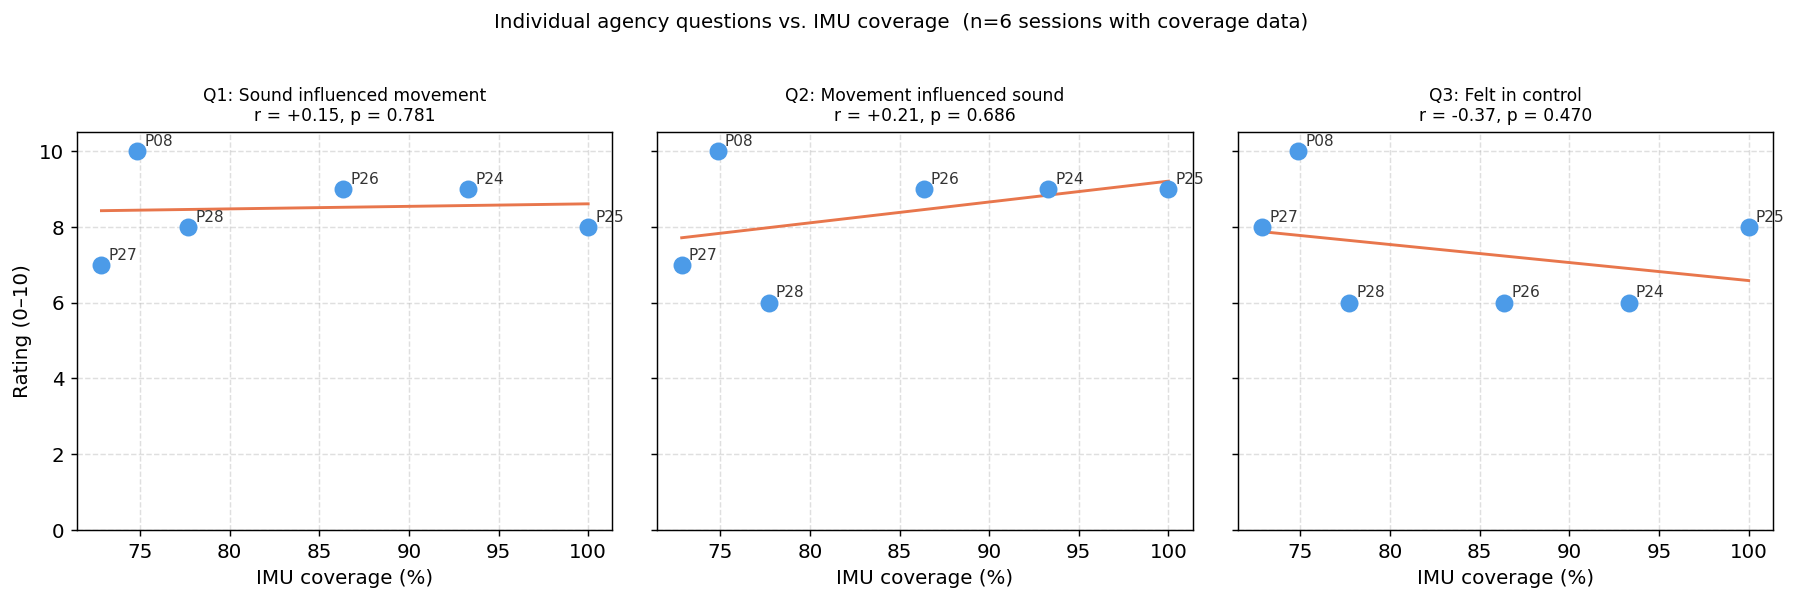

In [16]:
q_labels = {
    "agency_q1": "Q1: Sound influenced movement",
    "agency_q2": "Q2: Movement influenced sound",
    "agency_q3": "Q3: Felt in control",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (q_col, q_label) in zip(axes, q_labels.items()):
    sub = df.dropna(subset=["avg_coverage", q_col])
    x_vals = sub["avg_coverage"].values
    y_vals = sub[q_col].values
    pids   = sub["participant_id"].values

    ax.scatter(x_vals, y_vals, s=80, color="#4C9BE8", zorder=3)
    for xi, yi, pid in zip(x_vals, y_vals, pids):
        ax.annotate(f"P{pid}", xy=(xi, yi), xytext=(4, 3),
                    textcoords="offset points", fontsize=8.5, color="#333")

    if len(sub) >= 3:
        slope, intercept, *_ = stats.linregress(x_vals, y_vals)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="#E8764C", linewidth=1.6)
        rho, p = stats.spearmanr(x_vals, y_vals)
        rho_str = f"r = {rho:+.2f}, p = {p:.3f}"
    else:
        rho_str = "n < 3"

    ax.set_title(f"{q_label}\n{rho_str}", fontsize=9.5)
    ax.set_xlabel("IMU coverage (%)")
    ax.set_ylim(0, 10.5)
    ax.grid(linestyle="--", alpha=0.4)

axes[0].set_ylabel("Rating (0–10)")
plt.suptitle("Individual agency questions vs. IMU coverage  (n=6 sessions with coverage data)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 6. Summary

**Participants excluded:** P01, P02, P22 (pilot/incomplete sessions).  
**Remaining:** n = 6 sessions (P08, P23–P28), all with pressure data present.

**What the data shows:**

| Finding | Strength |
|---|---|
| IMU coverage % → agency | No signal (r ≈ +0.29) |
| Abs heel correlation → agency | No signal (r ≈ +0.23) |
| Flag count → agency | No signal once pressure-missing sessions are excluded |

**Interpretation:** Across the 6 sessions with working pressure systems, there is no discernible relationship between signal quality (coverage, heel correlation, flag count) and reported agency. Agency scores range from 6.7 to 10.0 with no pattern matching quality metrics. P08 stands out — worst heel correlation in the set but highest agency (10.0).

**Limitations:** n = 6. A Spearman correlation needs r > 0.81 for p < 0.05 at this sample size — this is descriptive only. Test 5 (n = 23) is the right place to revisit this question with adequate power.

---
## 6. Pressure time series — interactive

Select a participant to view their L heel and R heel pressure over time (pondering phase). Use the PID box to step through each participant.

In [19]:
import sys
sys.path.insert(0, "..")
from analysis.test5_gait_analysis import parse_condition_file, _parse_records
import ipywidgets as widgets
from IPython.display import display

AVAILABLE_PIDS = sorted([
    p for p in ["08", "23", "24", "25", "26", "27", "28"]
    if any((TEST4_RAW / p).glob("*pressure*"))
])

agency_lookup = df.set_index("participant_id")["agency_aggregate"].to_dict()

MS_PER_ROW = 30.77  # fallback; calibration files give participant-specific values


def get_ms_per_row(pid):
    """Estimate sampling interval from calibration file wall-clock timestamps."""
    cal = TEST4_RAW / pid / f"{pid}_pressure_calibration.csv"
    if not cal.exists():
        return MS_PER_ROW
    records = _parse_records(cal)
    timestamps = []
    for r in records:
        try:
            t = float(r[0])
            if t > 0:
                timestamps.append(t)
        except (ValueError, IndexError):
            continue
    if len(timestamps) < 10:
        return MS_PER_ROW
    ts = sorted(timestamps)
    diffs = [ts[i+1] - ts[i] for i in range(len(ts)-1)]
    diffs = [d for d in diffs if 5 < d < 200]
    return float(sorted(diffs)[len(diffs)//2]) if diffs else MS_PER_ROW


def load_calibration_phase(pid):
    """Parse the calibration pressure file (wall_clock, L_toe, L_heel, R_toe, R_heel)."""
    path = TEST4_RAW / pid / f"{pid}_pressure_calibration.csv"
    if not path.exists():
        return None
    records = _parse_records(path)
    rows = []
    for r in records:
        if len(r) < 5:
            continue
        try:
            rows.append({
                "L_toe":  float(r[1]),
                "L_heel": float(r[2]),
                "R_toe":  float(r[3]),
                "R_heel": float(r[4]),
            })
        except ValueError:
            continue
    if not rows:
        return None
    cal_df = pd.DataFrame(rows)
    interval = get_ms_per_row(pid)
    cal_df["time_s"] = cal_df.index * interval / 1000.0
    cal_df.attrs["time_source"] = f"reconstructed @ {interval:.1f} ms/row"
    cal_df.attrs["stem"] = "calibration"
    return cal_df


def load_pressure_phase(pid):
    """Load calibration heel pressure; fall back to pondering if unavailable."""
    cal_df = load_calibration_phase(pid)
    if cal_df is not None:
        return cal_df
    for stem in ("pondering", "tempo", "weight"):
        path = TEST4_RAW / pid / f"{pid}_pressure_{stem}.csv"
        if path.exists():
            phase_df, _ = parse_condition_file(path)
            if not {"L_heel", "R_heel"}.issubset(phase_df.columns):
                continue
            if phase_df["device_ms"].max() == 0:
                interval = get_ms_per_row(pid)
                phase_df["time_s"] = phase_df.index * interval / 1000.0
                time_source = f"reconstructed @ {interval:.1f} ms/row"
            else:
                phase_df["time_s"] = (phase_df["device_ms"] - phase_df["device_ms"].iloc[0]) / 1000.0
                time_source = "device clock"
            phase_df.attrs["time_source"] = time_source
            phase_df.attrs["stem"] = stem
            return phase_df
    return None


def plot_pressure(pid):
    phase_df = load_pressure_phase(pid)
    agency_val = agency_lookup.get(pid)
    agency_str = f"{agency_val:.1f}/10" if agency_val is not None else "N/A"

    # No sharex — both subplots show their own x-axis labels
    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.subplots_adjust(hspace=0.35)

    if phase_df is None:
        fig.suptitle(f"P{pid} — no pressure data found", fontsize=12)
        axes[0].text(0.5, 0.5, "No pressure data", ha="center", va="center",
                     transform=axes[0].transAxes)
        plt.show()
        return

    stem = phase_df.attrs.get("stem", "")
    time_source = phase_df.attrs.get("time_source", "")
    fig.suptitle(
        f"P{pid} — {stem} phase   |   Agency: {agency_str}   |   Time axis: {time_source}",
        fontsize=11
    )

    for ax, heel_col, lower_col, upper_col, color, label in [
        (axes[0], "L_heel", "L_heel_lower", "L_heel_upper", "#4C9BE8", "Left heel"),
        (axes[1], "R_heel", "R_heel_lower", "R_heel_upper", "#E8764C", "Right heel"),
    ]:
        ax.plot(phase_df["time_s"], phase_df[heel_col],
                color=color, linewidth=0.8, alpha=0.9, label=label)
        if {lower_col, upper_col}.issubset(phase_df.columns):
            ax.plot(phase_df["time_s"], phase_df[lower_col],
                    color="gray", linewidth=0.9, linestyle="--", alpha=0.6, label="lower threshold")
            ax.plot(phase_df["time_s"], phase_df[upper_col],
                    color="gray", linewidth=0.9, linestyle=":", alpha=0.6, label="upper threshold")
        ax.set_ylabel(f"{label} (raw units)", fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=10)
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(linestyle="--", alpha=0.35)

    plt.show()


pid_widget = widgets.Dropdown(
    options=AVAILABLE_PIDS,
    value=AVAILABLE_PIDS[0],
    description="PID:",
    style={"description_width": "40px"},
    layout=widgets.Layout(width="160px"),
)

out = widgets.Output()

def on_pid_change(change):
    out.clear_output(wait=True)
    with out:
        plot_pressure(change["new"])

pid_widget.observe(on_pid_change, names="value")

display(widgets.HBox([pid_widget]), out)
with out:
    plot_pressure(pid_widget.value)

Output()

---
## 7. Test 5 — Influence Table

Per-participant outcome categorisation and quantitative effect sizes for the full study (N = 23).

**Tempo outcomes:** how much did cadence change relative to the audio drift?
- `tempo_effect_pct` — cadence Δ% in the final third vs baseline
- `audio_change_pct` — how much the audio BPM actually changed
- `coupling_ratio` — cadence Δ% ÷ audio Δ% (1.0 = perfect tracking; 0 = no response; negative = opposite direction)

**Weight outcomes:** how much did stance phase change?
- `stance_pct` — heel stance duration Δ% vs baseline

**Outcome codes:** `influenced_intended` · `influenced_transient` · `influenced_opposite` · `no_effect`

In [ ]:
con = sqlite3.connect(DB_PATH)
influence_df = pd.read_sql_query(
    """
    SELECT
        s.participant_id                            AS P,
        s.condition_order                           AS order_,
        s.tempo_direction                           AS tempo_dir,
        sr.tempo_outcome                            AS tempo_outcome,
        ROUND(sr.tempo_effect_pct, 1)               AS cad_delta_pct,
        ROUND(sr.tempo_audio_change_pct, 1)         AS audio_delta_pct,
        ROUND(sr.tempo_coupling_ratio, 2)           AS coupling,
        sr.tempo_onset                              AS onset,
        s.weight_direction                          AS weight_dir,
        sr.weight_outcome                           AS weight_outcome,
        ROUND(sr.weight_effect_pct_stance, 1)       AS stance_delta_pct
    FROM sessions s
    JOIN session_reviews sr ON sr.session_id = s.session_id
    WHERE sr.is_excluded = 0
      AND sr.tempo_outcome NOT IN ('unreviewed', '')
    ORDER BY CAST(s.participant_id AS INTEGER)
    """,
    con,
)
con.close()

# ── Short labels for readability ──────────────────────────────────────────────
OUTCOME_SHORT = {
    "influenced_intended":  "✓ intended",
    "influenced_transient": "~ transient",
    "influenced_opposite":  "✗ opposite",
    "no_effect":            "— none",
    "unreviewed":           "?",
}
DIR_ARROW = {"speeding_up": "↑", "slowing_down": "↓",
             "increasing": "↑", "decreasing": "↓"}

influence_df["tempo_outcome"]  = influence_df["tempo_outcome"].map(OUTCOME_SHORT)
influence_df["weight_outcome"] = influence_df["weight_outcome"].map(
    lambda x: OUTCOME_SHORT.get(x, x) if isinstance(x, str) else x
)
influence_df["tempo_dir"]  = influence_df["tempo_dir"].map(DIR_ARROW)
influence_df["weight_dir"] = influence_df["weight_dir"].map(DIR_ARROW)
influence_df["order_"]     = influence_df["order_"].str.replace("-first", "")

influence_df.columns = [
    "P", "Order", "T.dir", "Tempo outcome",
    "Cad Δ%", "Audio Δ%", "Coupling", "Onset",
    "W.dir", "Weight outcome", "Stance Δ%",
]

# ── Style ─────────────────────────────────────────────────────────────────────
def colour_outcome(val):
    if isinstance(val, str):
        if "intended" in val:   return "color: #2a9d2a; font-weight: bold"
        if "transient" in val:  return "color: #d97706"
        if "opposite" in val:   return "color: #dc2626"
        if "none" in val:       return "color: #888"
    return ""

def colour_coupling(val):
    try:
        v = float(val)
        if v > 1.5:  return "color: #2a9d2a"
        if v < 0:    return "color: #dc2626"
    except (TypeError, ValueError):
        pass
    return ""

styled = (
    influence_df.style
    .applymap(colour_outcome, subset=["Tempo outcome", "Weight outcome"])
    .applymap(colour_coupling, subset=["Coupling"])
    .format({
        "Cad Δ%":    lambda x: f"{x:+.1f}%" if pd.notna(x) else "—",
        "Audio Δ%":  lambda x: f"{x:+.1f}%" if pd.notna(x) else "—",
        "Coupling":  lambda x: f"{x:+.2f}"  if pd.notna(x) else "—",
        "Stance Δ%": lambda x: f"{x:+.1f}%" if pd.notna(x) else "—",
    }, na_rep="—")
    .set_caption(
        "Test 5 (N=23): per-participant influence outcomes and effect sizes. "
        "Cad Δ% and Stance Δ% are relative to each participant's own baseline. "
        "Coupling = cadence Δ% ÷ audio Δ% (1.0 = perfect tracking)."
    )
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "11px"), ("text-align", "center")]},
        {"selector": "td", "props": [("font-size", "11px"), ("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "11px"), ("caption-side", "top"),
                                          ("text-align", "left"), ("color", "#555")]},
    ])
    .hide(axis="index")
)

styled